Student Social Media & Mental Health Impact

<hr>

Road Kill:https://roadkill.at/forschung-ergebnisse/daten
https://www.gbif.org/dataset/d0d5ef85-71b2-4da6-b6f6-c1c3d60987d3

Citation: Heigl, Florian, & Roadkill Community. (2025). Roadkill Dataset 2014-2023 Quality level 2 [Data set]. Zenodo. https://doi.org/10.5281/zenodo.5878813

Fragen:
    Welches Tier ist am Anfälligsten überfahren zu werden?
    Gibt es eine korrelation zwischen Größe und Tod?
    Wo/Wann werden die meisten Tiere überfahren und werden es mehr über die jahre?
        

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [6]:

# ==========================================
# 1. LOAD DATA
# ==========================================

df = pd.read_csv("data\Student_Social_Media_And_Mental_Health_Impact.csv")

print("\nFIRST 5 ROWS")
print(df.head())

print("\nDATA INFO")
print(df.info())

print("\nMISSING VALUES")
print(df.isnull().sum())


FIRST 5 ROWS
   Age  Gender Country Academic_Level Most_Used_Platform Purpose_Of_Use  \
0   21    Male   Other  Undergraduate           Facebook     Networking   
1   23  Female   Other       Graduate           LinkedIn      Education   
2   22    Male  Canada  Undergraduate          Instagram  Entertainment   
3   18    Male   Other    High School           Snapchat  Entertainment   
4   24  Female   Other       Graduate           Facebook     Networking   

   Avg_Daily_Usage_Hours  Daily_Unlocks  Study_Hours  Physical_Activity_Hours  \
0                    4.0            134          4.5                      2.2   
1                    1.6             73          7.0                      2.4   
2                    4.6            166          4.0                      1.8   
3                    7.0            220          1.0                      1.7   
4                    7.5            237          1.0                      1.1   

   Sleep_Hours_Per_Night Stress_Level  Mental_He

<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\S'
C:\Users\User\AppData\Local\Temp\ipykernel_7352\3505346384.py:5: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv("data\Student_Social_Media_And_Mental_Health_Impact.csv")



DESCRIPTIVE STATISTICS
               Age  Avg_Daily_Usage_Hours  Daily_Unlocks  Study_Hours  \
count  4998.000000            4998.000000    4998.000000  4998.000000   
mean     20.822129               5.078491     171.455582     3.008403   
std       1.736774               1.654097      42.859829     1.636831   
min      18.000000               1.000000      62.000000     0.300000   
25%      19.000000               3.800000     140.000000     1.500000   
50%      21.000000               5.000000     171.000000     2.800000   
75%      22.000000               6.300000     204.000000     4.200000   
max      24.000000               8.800000     273.000000     8.300000   

       Physical_Activity_Hours  Sleep_Hours_Per_Night  Mental_Health_Score  \
count              4998.000000            4998.000000          4998.000000   
mean                  1.750760               6.634654             6.231152   
std                   0.668406               1.221561             1.278476   
min   

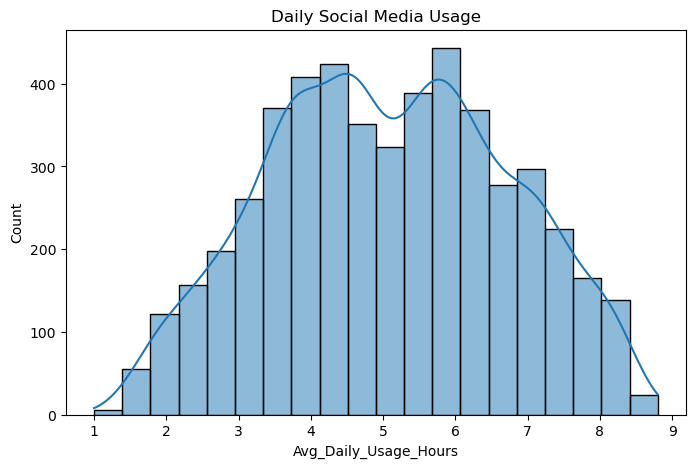

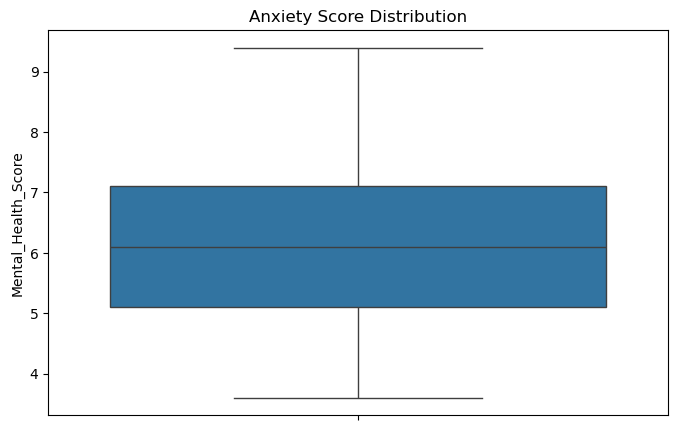

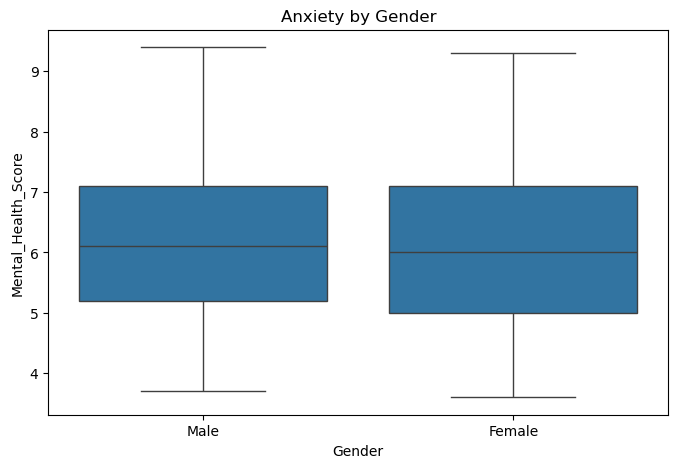

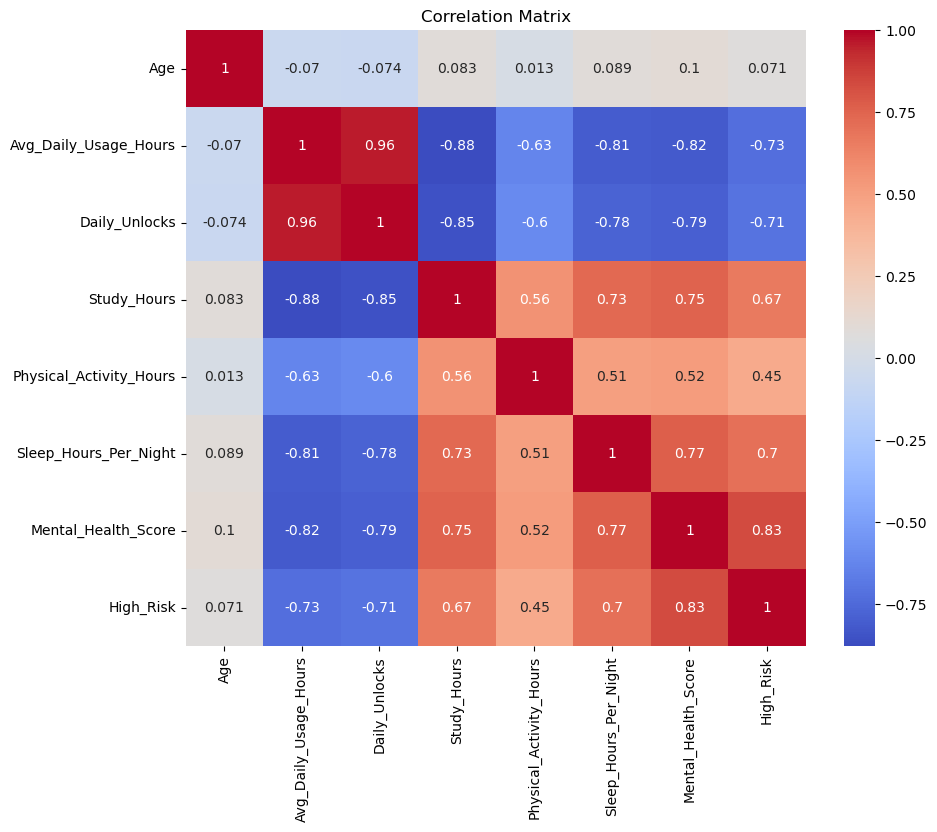


Correlation Results
Correlation = -0.816
P-value = 0.00000

T-TEST RESULTS
H0: No anxiety difference
H1: Heavy users have different anxiety
T-statistic: -72.851
P-value: 0.0
Significant Difference Found

LINEAR REGRESSION
RMSE: 0.716
R²: 0.713

RANDOM FOREST RESULTS
Accuracy: 0.868

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.86      0.87       521
           1       0.85      0.88      0.86       479

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000


FEATURE IMPORTANCE
                 Feature  Importance
0  Avg_Daily_Usage_Hours    0.532448
1  Sleep_Hours_Per_Night    0.467552


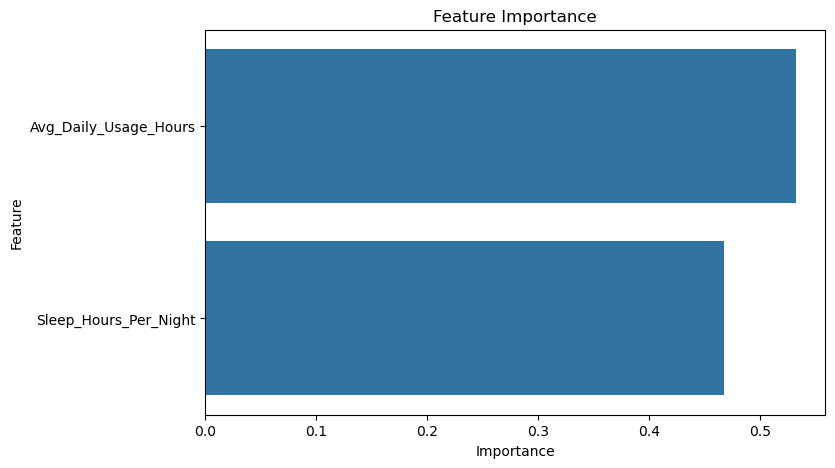

ValueError: could not convert string to float: 'Medium'

In [10]:
# ==========================================
# 2. DATA CLEANING
# ==========================================

df = df.drop_duplicates()

# Fill numerical missing values
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# ==========================================
# IMPORTANT
# Replace these names if needed
# ==========================================

SOCIAL_MEDIA_HOURS = "Avg_Daily_Usage_Hours"
ANXIETY = "Mental_Health_Score"
#DEPRESSION = "Depression_Score"
STRESS = "Stress_Level"
SLEEP = "Sleep_Hours_Per_Night"
GENDER = "Gender"

# ==========================================
# 3. DESCRIPTIVE STATISTICS
# ==========================================

print("\nDESCRIPTIVE STATISTICS")
print(df.describe())

# ==========================================
# 4. EDA VISUALIZATIONS
# ==========================================

plt.figure(figsize=(8,5))
sns.histplot(df[SOCIAL_MEDIA_HOURS], bins=20, kde=True)
plt.title("Daily Social Media Usage")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(y=df[ANXIETY])
plt.title("Anxiety Score Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df[GENDER], y=df[ANXIETY])
plt.title("Anxiety by Gender")
plt.show()

# ==========================================
# 5. CORRELATION ANALYSIS
# ==========================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

corr, p_value = stats.pearsonr(
    df[SOCIAL_MEDIA_HOURS],
    df[ANXIETY]
)

print("\nCorrelation Results")
print(f"Correlation = {corr:.3f}")
print(f"P-value = {p_value:.5f}")

# ==========================================
# 6. HYPOTHESIS TEST
# ==========================================

heavy_users = df[df[SOCIAL_MEDIA_HOURS] > 4]
light_users = df[df[SOCIAL_MEDIA_HOURS] <= 4]

t_stat, p_val = stats.ttest_ind(
    heavy_users[ANXIETY],
    light_users[ANXIETY]
)

print("\nT-TEST RESULTS")
print("H0: No anxiety difference")
print("H1: Heavy users have different anxiety")

print("T-statistic:", round(t_stat,3))
print("P-value:", round(p_val,5))

if p_val < 0.05:
    print("Significant Difference Found")
else:
    print("No Significant Difference")

# ==========================================
# 7. LINEAR REGRESSION
# Predict Anxiety
# ==========================================

features = [
    SOCIAL_MEDIA_HOURS,
    SLEEP
]

X = df[features]
y = df[ANXIETY]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

reg_model = LinearRegression()

reg_model.fit(X_train, y_train)

predictions = reg_model.predict(X_test)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

r2 = r2_score(
    y_test,
    predictions
)

print("\nLINEAR REGRESSION")
print("RMSE:", round(rmse,3))
print("R²:", round(r2,3))

# ==========================================
# 8. HIGH-RISK CLASSIFICATION
# ==========================================

threshold = df[ANXIETY].median()

df["High_Risk"] = (
    df[ANXIETY] > threshold
).astype(int)

X = df[features]
y = df["High_Risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("\nRANDOM FOREST RESULTS")
print("Accuracy:", accuracy_score(y_test, pred))

print("\nClassification Report")
print(classification_report(y_test, pred))

# ==========================================
# 9. FEATURE IMPORTANCE
# ==========================================

importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFEATURE IMPORTANCE")
print(importance)

plt.figure(figsize=(8,5))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importance")
plt.show()

# ==========================================
# 10. CLUSTERING
# ==========================================

cluster_features = [
    SOCIAL_MEDIA_HOURS,
    ANXIETY,
    STRESS
]

cluster_data = df[cluster_features]

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(
    cluster_data
)

pca = PCA(n_components=2)

reduced = pca.fit_transform(
    cluster_data
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=reduced[:,0],
    y=reduced[:,1],
    hue=df["Cluster"],
    palette="Set1"
)

plt.title("Student Clusters")
plt.show()

# ==========================================
# 11. SUMMARY
# ==========================================

print("\nPROJECT SUMMARY")

print(
    f"Social Media vs Anxiety Correlation: {corr:.3f}"
)

print(
    f"Regression R²: {r2:.3f}"
)

print(
    f"Classification Accuracy: "
    f"{accuracy_score(y_test, pred):.3f}"
)

print("\nProject Complete")